## EDA on Preprocessed Trek Dataset


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Dataset Loading & Inspection

We load the preprocessed datasets produced by the `preprocessing/` pipeline.
- **Unscaled** dataset is used for all EDA, since the original values are interpretable.
- **Scaled** dataset is available for ML-ready feature inspection.


In [2]:
# Load preprocessed datasets
df = pd.read_csv('datasets/processed/trek_preprocessed_unscaled.csv')
df_scaled = pd.read_csv('datasets/processed/trek_preprocessed_scaled.csv')

print(f"Unscaled Dataset Shape: {df.shape}")
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Unscaled Dataset Shape: (383, 15)

Rows: 383, Columns: 15


,Trek,Cost_USD,Duration_Days,Max_Altitude_m,Trip_Grade_Ordinal,Accom_Guesthouse,Accom_Lodge,Accom_LuxuryLodge,Accom_Teahouse,Accom_TeahouseLodge,Travel_AprMay_SeptNov,Travel_JanMay_SeptDec,Travel_MarMay_SeptDec,Travel_MarMay_SeptNov,Travel_MarNov
0,Everest Base Camp Trek,1420.0,16,5545,4,1,0,0,0,0,0,0,1,0,0
1,Everest Base Camp Short Trek,1295.0,14,5545,4,1,0,0,0,0,0,0,1,0,0
2,Everest Base Camp Heli Shuttle Trek,2000.0,12,5545,4,1,0,0,0,0,0,0,1,0,0
3,Everest Base Camp Heli Trek,3300.0,11,5545,4,1,0,0,0,0,0,0,1,0,0
4,Everest Base Camp Trek for Seniors,1800.0,20,5545,4,1,0,0,0,0,0,0,1,0,0


In [3]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trek                   383 non-null    object 
 1   Cost_USD               383 non-null    float64
 2   Duration_Days          383 non-null    int64  
 3   Max_Altitude_m         383 non-null    int64  
 4   Trip_Grade_Ordinal     383 non-null    int64  
 5   Accom_Guesthouse       383 non-null    int64  
 6   Accom_Lodge            383 non-null    int64  
 7   Accom_LuxuryLodge      383 non-null    int64  
 8   Accom_Teahouse         383 non-null    int64  
 9   Accom_TeahouseLodge    383 non-null    int64  
 10  Travel_AprMay_SeptNov  383 non-null    int64  
 11  Travel_JanMay_SeptDec  383 non-null    int64  
 12  Travel_MarMay_SeptDec  383 non-null    int64  
 13  Travel_MarMay_SeptNov  383 non-null    int64  
 14  Travel_MarNov          383 non-null    int64  
dtypes: flo

In [4]:
# Statistical summary of numeric features
df.describe().round(2)

,Cost_USD,Duration_Days,Max_Altitude_m,Trip_Grade_Ordinal,Accom_Guesthouse,Accom_Lodge,Accom_LuxuryLodge,Accom_Teahouse,Accom_TeahouseLodge,Travel_AprMay_SeptNov,Travel_JanMay_SeptDec,Travel_MarMay_SeptDec,Travel_MarMay_SeptNov,Travel_MarNov
count,383.00,383.00,383.00,383.0,383.00,383.00,383.00,383.00,383.00,383.00,383.00,383.00,383.00,383.00
mean,1415.97,14.56,4640.16,4.6,0.84,0.03,0.01,0.11,0.01,0.00,0.71,0.17,0.11,0.01
std,466.10,4.54,1022.51,1.6,0.37,0.16,0.11,0.31,0.11,0.05,0.45,0.37,0.31,0.11
min,450.00,5.00,1550.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1190.00,11.00,4130.00,3.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1499.00,14.00,5050.00,4.0,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
75%,1499.00,18.00,5416.00,6.0,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
max,4200.00,27.00,6340.00,8.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [5]:
# Null value check
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print("Null value report:")
print(null_df)

Null value report:
                       Null Count  Null %
Trek                            0     0.0
Cost_USD                        0     0.0
Duration_Days                   0     0.0
Max_Altitude_m                  0     0.0
Trip_Grade_Ordinal              0     0.0
Accom_Guesthouse                0     0.0
Accom_Lodge                     0     0.0
Accom_LuxuryLodge               0     0.0
Accom_Teahouse                  0     0.0
Accom_TeahouseLodge             0     0.0
Travel_AprMay_SeptNov           0     0.0
Travel_JanMay_SeptDec           0     0.0
Travel_MarMay_SeptDec           0     0.0
Travel_MarMay_SeptNov           0     0.0
Travel_MarNov                   0     0.0


In [6]:
# Unique values per column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Trek: 68 unique values
Cost_USD: 38 unique values
Duration_Days: 19 unique values
Max_Altitude_m: 36 unique values
Trip_Grade_Ordinal: 8 unique values
Accom_Guesthouse: 2 unique values
Accom_Lodge: 2 unique values
Accom_LuxuryLodge: 2 unique values
Accom_Teahouse: 2 unique values
Accom_TeahouseLodge: 2 unique values
Travel_AprMay_SeptNov: 2 unique values
Travel_JanMay_SeptDec: 2 unique values
Travel_MarMay_SeptDec: 2 unique values
Travel_MarMay_SeptNov: 2 unique values
Travel_MarNov: 2 unique values


## 3. Trek Name Distribution

The raw dataset has multiple entries per trek (from different agencies). This shows the most frequent trek names.


In [7]:
# Most common trek names
print(f"Total rows: {len(df)}")
print(f"Unique trek names: {df['Trek'].nunique()}")
print(f"\nMost duplicated treks (top 10):")
print(df['Trek'].value_counts().head(10))

Total rows: 383
Unique trek names: 68

Most duplicated treks (top 10):
Trek
Annapurna Circuit Trek         15
Manaslu Circuit Trek           15
Annapurna Base Camp Trek       15
Mardi Himal Trek               15
Upper Mustang Trek             15
Everest Base Camp Trek         11
Tamang Heritage Trek           10
Langtang Valley Trek           10
Everest View Trek               6
Everest Base Camp Heli Trek     6
Name: count, dtype: int64


## 4. Distributions of Key Numeric Features

We visualize the distribution of the four core numeric features in the preprocessed dataset:
- **Cost_USD** — Trek cost in US dollars
- **Duration_Days** — Trek duration in days
- **Max_Altitude_m** — Maximum altitude in meters
- **Trip_Grade_Ordinal** — Difficulty score (1=Easy, 5=Strenuous)


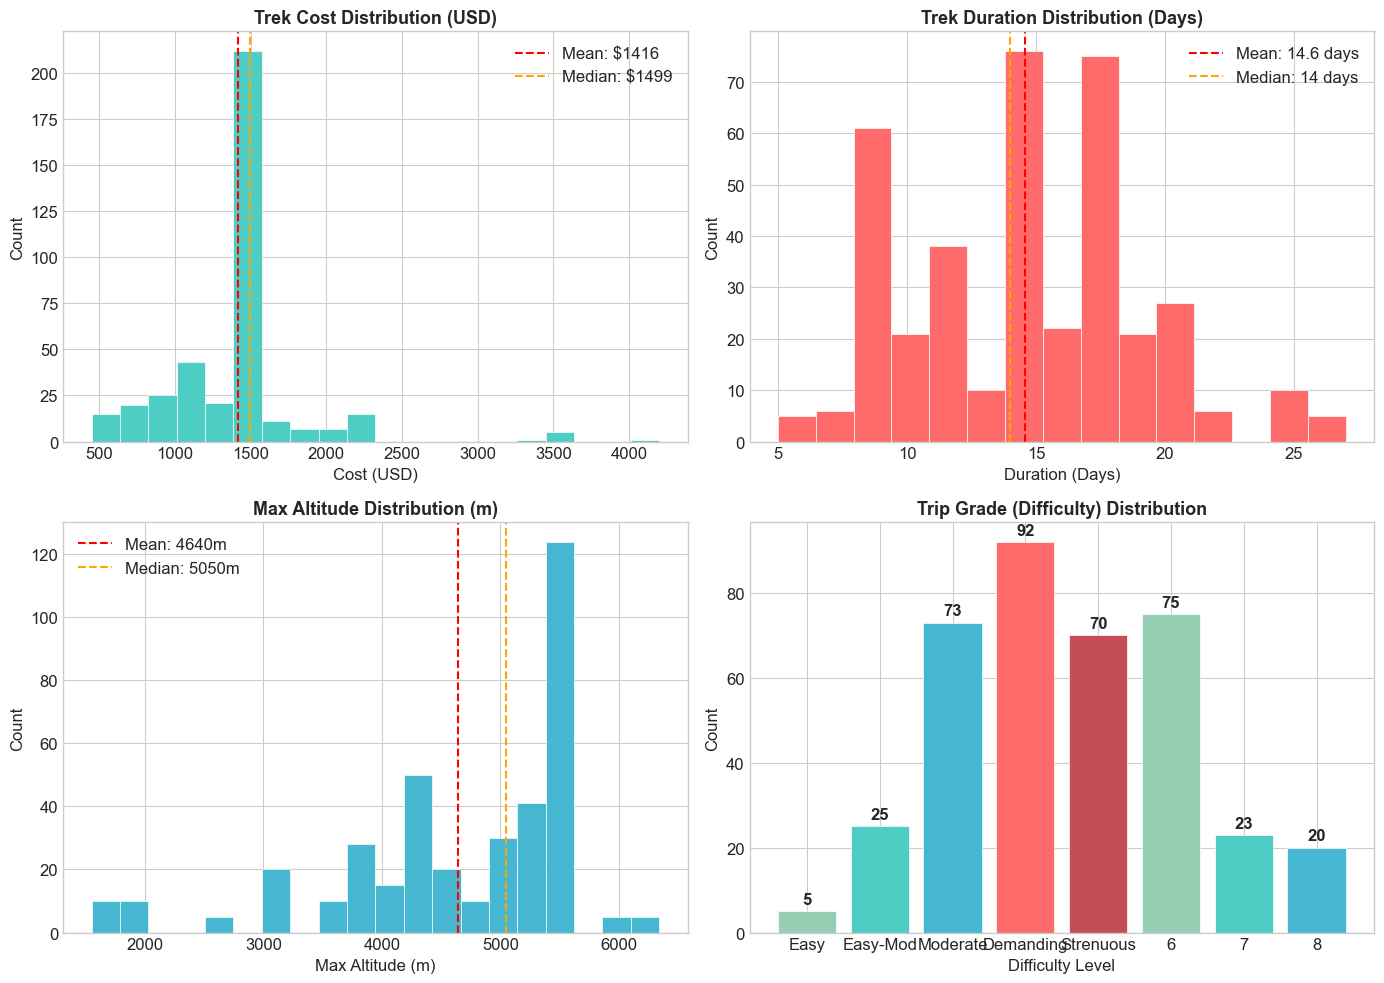

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cost distribution
axes[0, 0].hist(df['Cost_USD'], bins=20, color='#4ECDC4', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Trek Cost Distribution (USD)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Cost (USD)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['Cost_USD'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Cost_USD"].mean():.0f}')
axes[0, 0].axvline(df['Cost_USD'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: ${df["Cost_USD"].median():.0f}')
axes[0, 0].legend()

# Duration distribution
axes[0, 1].hist(df['Duration_Days'], bins=15, color='#FF6B6B', edgecolor='white', linewidth=0.5)
axes[0, 1].set_title('Trek Duration Distribution (Days)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Duration (Days)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(df['Duration_Days'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["Duration_Days"].mean():.1f} days')
axes[0, 1].axvline(df['Duration_Days'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["Duration_Days"].median():.0f} days')
axes[0, 1].legend()

# Max Altitude distribution
axes[1, 0].hist(df['Max_Altitude_m'], bins=20, color='#45B7D1', edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Max Altitude Distribution (m)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Max Altitude (m)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(df['Max_Altitude_m'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["Max_Altitude_m"].mean():.0f}m')
axes[1, 0].axvline(df['Max_Altitude_m'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["Max_Altitude_m"].median():.0f}m')
axes[1, 0].legend()

# Trip Grade distribution
grade_labels = {1: 'Easy', 2: 'Easy-Mod', 3: 'Moderate', 4: 'Demanding', 5: 'Strenuous'}
grade_counts = df['Trip_Grade_Ordinal'].value_counts().sort_index()
bars = axes[1, 1].bar(
    [grade_labels.get(g, str(g)) for g in grade_counts.index],
    grade_counts.values,
    color=['#96CEB4', '#4ECDC4', '#45B7D1', '#FF6B6B', '#C44D58'],
    edgecolor='white', linewidth=0.5
)
axes[1, 1].set_title('Trip Grade (Difficulty) Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Difficulty Level')
axes[1, 1].set_ylabel('Count')
for bar, count in zip(bars, grade_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Accommodation Type & Best Travel Season

The preprocessed data uses **one-hot encoding** for accommodation type and best travel season.
We decode these back for interpretable visualizations.


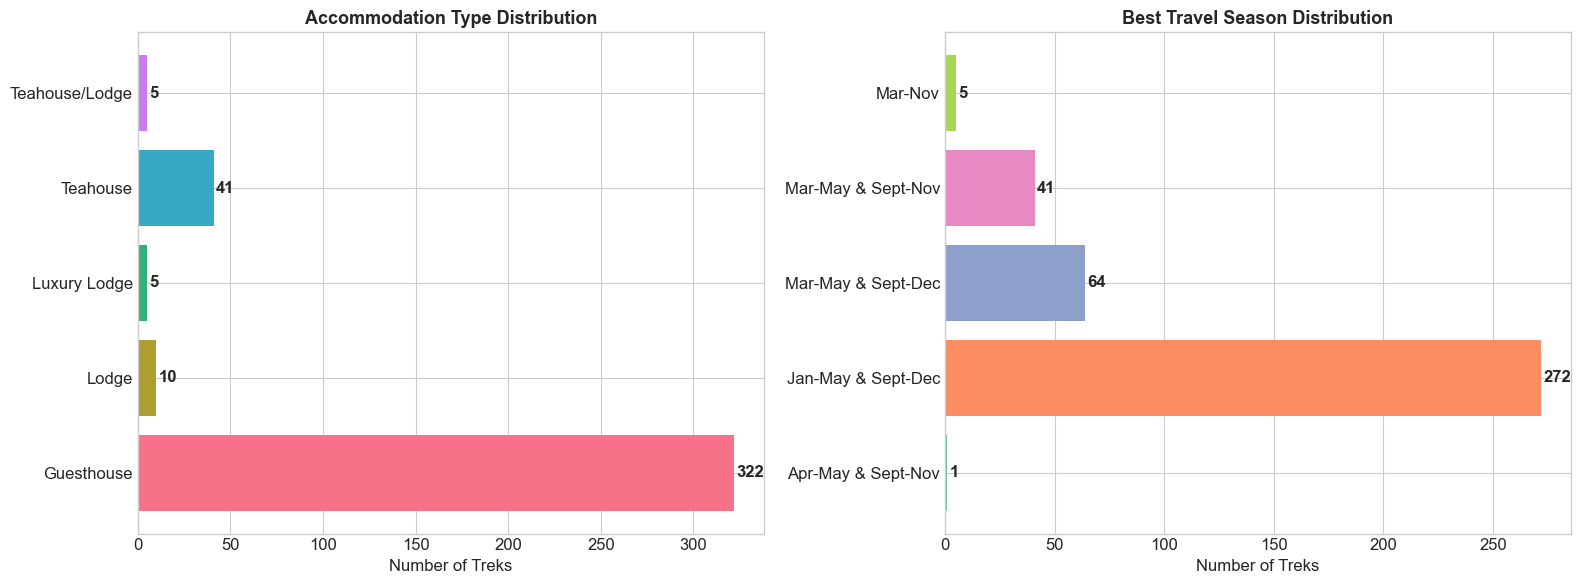

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accommodation distribution
accom_cols = ['Accom_Guesthouse', 'Accom_Lodge', 'Accom_LuxuryLodge', 'Accom_Teahouse', 'Accom_TeahouseLodge']
accom_labels = ['Guesthouse', 'Lodge', 'Luxury Lodge', 'Teahouse', 'Teahouse/Lodge']
accom_counts = df[accom_cols].sum().values

bars = axes[0].barh(accom_labels, accom_counts, color=sns.color_palette('husl', len(accom_labels)))
axes[0].set_title('Accommodation Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Treks')
for bar, count in zip(bars, accom_counts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(int(count)), ha='left', va='center', fontweight='bold')

# Travel season distribution
season_cols = ['Travel_AprMay_SeptNov', 'Travel_JanMay_SeptDec', 'Travel_MarMay_SeptDec',
               'Travel_MarMay_SeptNov', 'Travel_MarNov']
season_labels = ['Apr-May & Sept-Nov', 'Jan-May & Sept-Dec', 'Mar-May & Sept-Dec',
                 'Mar-May & Sept-Nov', 'Mar-Nov']
season_counts = df[season_cols].sum().values

bars2 = axes[1].barh(season_labels, season_counts, color=sns.color_palette('Set2', len(season_labels)))
axes[1].set_title('Best Travel Season Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Treks')
for bar, count in zip(bars2, season_counts):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(int(count)), ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

A heatmap of the Pearson correlation coefficients between all numeric features.


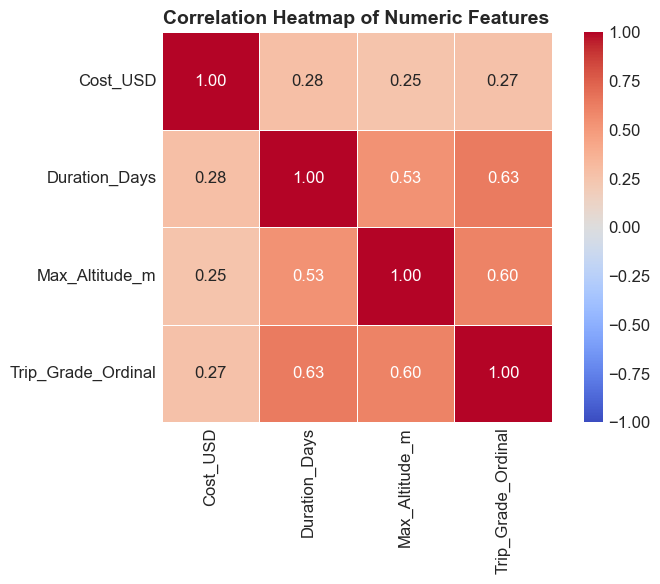

In [10]:
numeric_cols = ['Cost_USD', 'Duration_Days', 'Max_Altitude_m', 'Trip_Grade_Ordinal']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Key Relationships Between Features


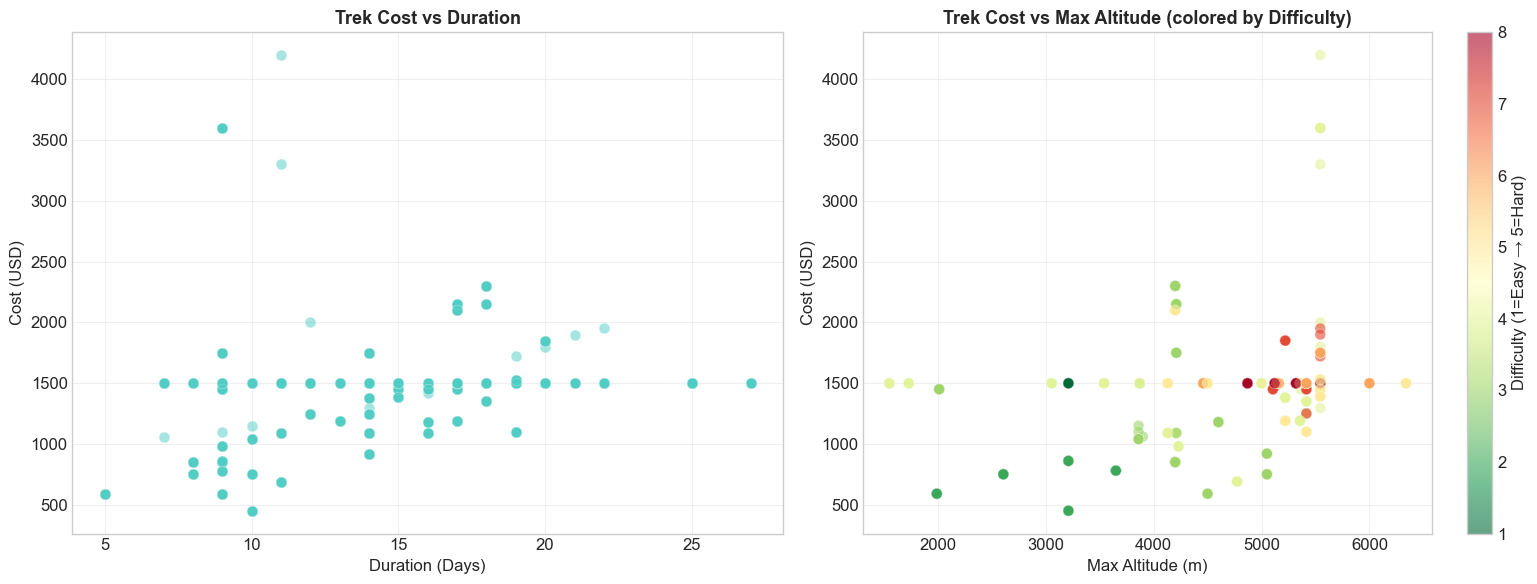

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cost vs Duration
axes[0].scatter(df['Duration_Days'], df['Cost_USD'], alpha=0.5, color='#4ECDC4', edgecolors='white', linewidth=0.3, s=60)
axes[0].set_title('Trek Cost vs Duration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (Days)')
axes[0].set_ylabel('Cost (USD)')
axes[0].grid(True, alpha=0.3)

# Cost vs Max Altitude
scatter = axes[1].scatter(df['Max_Altitude_m'], df['Cost_USD'],
                          c=df['Trip_Grade_Ordinal'], cmap='RdYlGn_r',
                          alpha=0.6, edgecolors='white', linewidth=0.3, s=60)
plt.colorbar(scatter, ax=axes[1], label='Difficulty (1=Easy → 5=Hard)')
axes[1].set_title('Trek Cost vs Max Altitude (colored by Difficulty)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Altitude (m)')
axes[1].set_ylabel('Cost (USD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Distributions by Difficulty Grade

How does Cost, Duration, and Altitude vary across different difficulty levels?


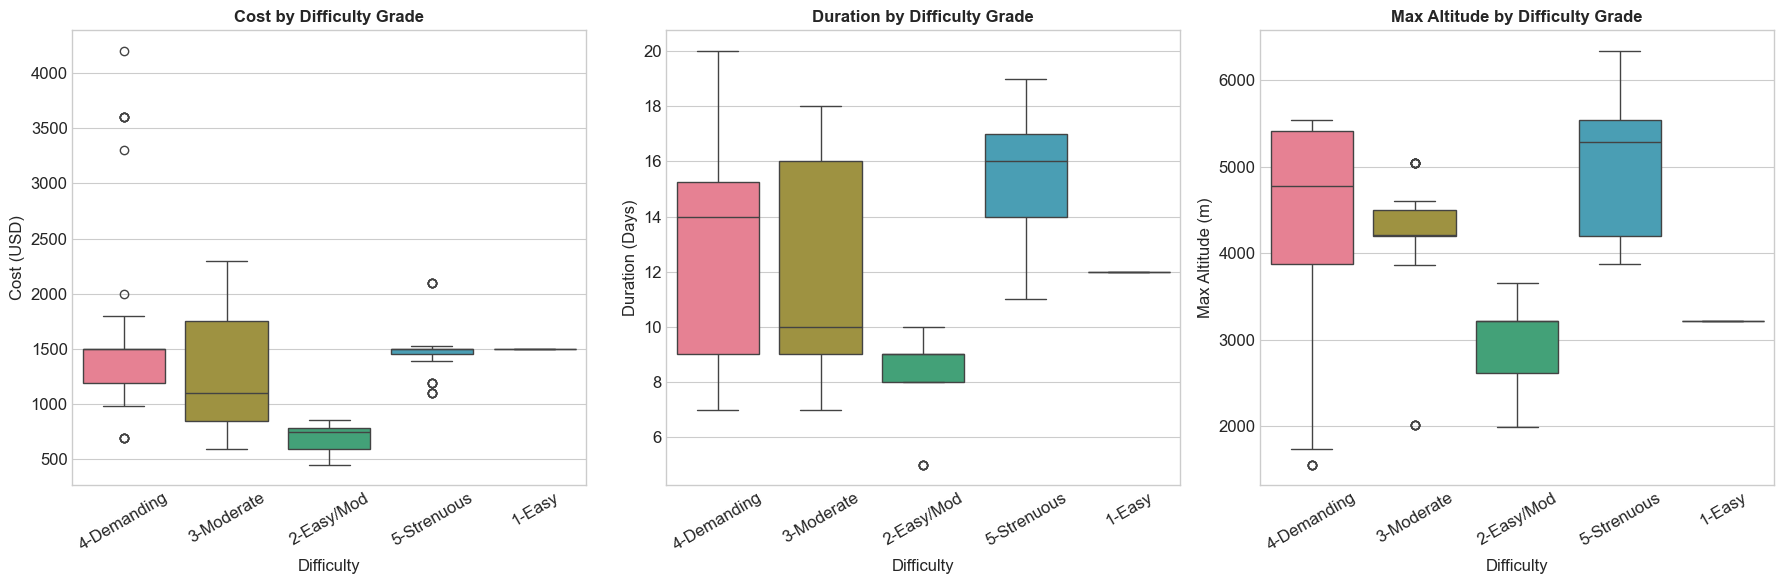

In [12]:
grade_labels = {1: '1-Easy', 2: '2-Easy/Mod', 3: '3-Moderate', 4: '4-Demanding', 5: '5-Strenuous'}
df['Grade_Label'] = df['Trip_Grade_Ordinal'].map(grade_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=df, x='Grade_Label', y='Cost_USD', ax=axes[0], palette='husl')
axes[0].set_title('Cost by Difficulty Grade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Difficulty')
axes[0].set_ylabel('Cost (USD)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Grade_Label', y='Duration_Days', ax=axes[1], palette='husl')
axes[1].set_title('Duration by Difficulty Grade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Duration (Days)')
axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Grade_Label', y='Max_Altitude_m', ax=axes[2], palette='husl')
axes[2].set_title('Max Altitude by Difficulty Grade', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Difficulty')
axes[2].set_ylabel('Max Altitude (m)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Top & Bottom Treks by Key Features

Looking at the most extreme treks in terms of cost, duration, and altitude.


In [13]:
# Use deduplicated dataset for top/bottom analysis
df_unique = df.drop_duplicates(subset=['Trek']).reset_index(drop=True)

print("=" * 70)
print("💰 TOP 10 MOST EXPENSIVE TREKS")
print("=" * 70)
top_cost = df_unique.nlargest(10, 'Cost_USD')[['Trek', 'Cost_USD', 'Duration_Days', 'Max_Altitude_m', 'Trip_Grade_Ordinal']]
print(top_cost.to_string(index=False))

print("\n" + "=" * 70)
print("💸 TOP 10 BUDGET TREKS")
print("=" * 70)
bot_cost = df_unique.nsmallest(10, 'Cost_USD')[['Trek', 'Cost_USD', 'Duration_Days', 'Max_Altitude_m', 'Trip_Grade_Ordinal']]
print(bot_cost.to_string(index=False))

💰 TOP 10 MOST EXPENSIVE TREKS
                                               Trek  Cost_USD  Duration_Days  Max_Altitude_m  Trip_Grade_Ordinal
                 Luxury Everest Base Camp Heli Trek    4200.0             11            5545                   4
                        Everest Base Camp Heli Trek    3300.0             11            5545                   4
                       Upper Mustang Trek with Yara    2300.0             18            4200                   3
                                 Upper Mustang Trek    2150.0             17            4210                   3
                   Upper Mustang Tiji Festival Trek    2150.0             18            4210                   3
                Everest Base Camp Heli Shuttle Trek    2000.0             12            5545                   4
                           Everest High Passes Trek    1950.0             22            5545                   7
Everest Base Camp Trek with Chola and Renjo La Pass    1900.0     

In [14]:
print("=" * 70)
print("🏔️ TOP 10 HIGHEST ALTITUDE TREKS")
print("=" * 70)
top_alt = df_unique.nlargest(10, 'Max_Altitude_m')[['Trek', 'Max_Altitude_m', 'Cost_USD', 'Duration_Days', 'Trip_Grade_Ordinal']]
print(top_alt.to_string(index=False))

print("\n" + "=" * 70)
print("📅 TOP 10 LONGEST TREKS")
print("=" * 70)
top_dur = df_unique.nlargest(10, 'Duration_Days')[['Trek', 'Duration_Days', 'Cost_USD', 'Max_Altitude_m', 'Trip_Grade_Ordinal']]
print(top_dur.to_string(index=False))

🏔️ TOP 10 HIGHEST ALTITUDE TREKS
                                      Trek  Max_Altitude_m  Cost_USD  Duration_Days  Trip_Grade_Ordinal
Everest Advanced Base Camp Trek from Tibet            6340    1499.0             18                   5
                          Tsum Valley Trek            6000    1499.0             19                   6
                    Everest Base Camp Trek            5545    1420.0             16                   4
              Everest Base Camp Short Trek            5545    1295.0             14                   4
       Everest Base Camp Heli Shuttle Trek            5545    2000.0             12                   4
               Everest Base Camp Heli Trek            5545    3300.0             11                   4
        Everest Base Camp Trek for Seniors            5545    1800.0             20                   4
                   Everest Chola Pass Trek            5545    1720.0             19                   7
                  Everest High 

## 10. Scaled Dataset Preview

A quick look at the scaled version of the data (as produced by `StandardScaler` in the preprocessing pipeline).
This is the version used directly in the K-Means clustering and KNN notebooks.


In [15]:
print(f"Scaled Dataset Shape: {df_scaled.shape}")
print(f"\nFeatures (columns): {df_scaled.columns.tolist()}")
print()
df_scaled.describe().round(3)

Scaled Dataset Shape: (383, 15)

Features (columns): ['Trek', 'Cost_USD', 'Duration_Days', 'Max_Altitude_m', 'Trip_Grade_Ordinal', 'Accom_Guesthouse', 'Accom_Lodge', 'Accom_LuxuryLodge', 'Accom_Teahouse', 'Accom_TeahouseLodge', 'Travel_AprMay_SeptNov', 'Travel_JanMay_SeptDec', 'Travel_MarMay_SeptDec', 'Travel_MarMay_SeptNov', 'Travel_MarNov']



,Cost_USD,Duration_Days,Max_Altitude_m,Trip_Grade_Ordinal,Accom_Guesthouse,Accom_Lodge,Accom_LuxuryLodge,Accom_Teahouse,Accom_TeahouseLodge,Travel_AprMay_SeptNov,Travel_JanMay_SeptDec,Travel_MarMay_SeptDec,Travel_MarMay_SeptNov,Travel_MarNov
count,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000,383.000
mean,1415.966,-0.000,0.000,0.000,0.841,0.026,0.013,0.107,0.013,0.003,0.710,0.167,0.107,0.013
std,466.105,1.001,1.001,1.001,0.366,0.160,0.114,0.310,0.114,0.051,0.454,0.374,0.310,0.114
min,450.000,-2.108,-3.026,-2.257,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1190.000,-0.786,-0.500,-1.004,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,1499.000,-0.124,0.401,-0.378,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
75%,1499.000,0.757,0.760,0.875,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
max,4200.000,2.741,1.665,2.128,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
